# Clustering analysis

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from anomaly.utils import get_sdss_spec_img
from anomaly.constants import SDSS_NEBULAR_LINES_RATIOS_NAMES
from astroExplain.spectra import clustering
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data igestion

In [2]:
def load_xai(run_id: str, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_arr = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")
    weights = np.load(f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r")
    return anomalies_arr, specobjids_arr, weights

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "unique_norm_weights": None,
        "norm_unique_norm_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["unique_norm_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["norm_weights"], n_segments=n_segments
    )

    data_dict["norm_unique_norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_norm_weights"]
    )

    return data_dict

## Top ranked explanations

In [4]:
def plot_top_ranked_explanations(
    metadata_df,
    spectra,
    norm_weights,
    wave,
    kmeans_model_dir,
    cluster_id,
    download_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
    skip_ranks_list=[-1],
):

    lw = 0.75

    n_anomalies_in_cluster = metadata_df.shape[0]
    print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

    for anomaly_rank in range(0, n_anomalies_in_cluster):

        if anomaly_rank == n_top_ranked:
            break
        if anomaly_rank + 1 in skip_ranks_list:
            print(f"Skipping rank {anomaly_rank + 1}.", end="\n")
            continue

        print(f"Explanation for anomaly rank {anomaly_rank + 1}", end="\r")

        specobjid = metadata_df.index[anomaly_rank]

        if download_images is True:
            os.makedirs(f"{kmeans_model_dir}/cluster_{cluster_id}", exist_ok=True)

            # check if the image already exists
            image_path = (
                f"{kmeans_model_dir}/cluster_{cluster_id}/image_{specobjid}.jpeg"
            )

            if not os.path.exists(image_path):

                ra, dec = metadata_df[["ra", "dec"]].loc[specobjid].values

                get_sdss_spec_img(
                    specobjid,
                    ra,
                    dec,
                    save_to=f"{kmeans_model_dir}/cluster_{cluster_id}",
                )

        spec = spectra[anomaly_rank]

        norm_weights_spec = norm_weights[anomaly_rank]
        if max_norm_weights is True:
            norm_weights_spec /= np.max(norm_weights_spec)

        fig, axs = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(20, 7),
            sharex=True,
            sharey=False,
        )
        # set minor ticks on
        for ax in axs.flatten():
            ax.minorticks_on()
        axs[0].plot(wave, spec, color="black", linewidth=lw)
        # weights
        axs[1].plot(
            wave, norm_weights_spec, color="black",
            label=f"Cluster {cluster_id}", linewidth=lw
        )

        axs[1].set_xlabel(r"$\lambda$ [nm]")
        axs[0].set_ylabel("Normalized flux")
        axs[1].set_ylabel("Explanation weights")
        axs[0].set_title(
            f"Rank: {anomaly_rank + 1:02d} - Cluster: {cluster_id}\n"
            f"Specobjid: {specobjid}"
        )

        axs[1].set_ylim(0, 0.4)
        y_ticks = np.arange(0, 0.41, 0.1)
        axs[1].set_yticks(y_ticks)

        if download_images is True:
            image_name = f"image_{specobjid}.jpeg"
        # Load the image
            img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")

            # Create inset in top-right corner of axs[0]
            width_height_image = 1
            axins = inset_axes(
                axs[0],
                width=width_height_image,
                height=width_height_image,
                bbox_to_anchor=(1.01, 1.02),
                bbox_transform=axs[0].transAxes,
                loc="upper right",
            )

            # Show image in the inset
            axins.imshow(img)
            axins.axis("off")  # Hide axis around the image
        explanation_name = f"rank_{anomaly_rank + 1:02d}_explanation_{specobjid}"
        if max_norm_weights is True:
            explanation_name += "_max_norm"

        save_pdf_dir = f"{kmeans_model_dir}/cluster_{cluster_id}"
        save_jpeg_dir = f"{save_pdf_dir}/explanations_sdss_spec_jpeg"
        # create directories if they don't exist
        os.makedirs(save_pdf_dir, exist_ok=True)
        os.makedirs(save_jpeg_dir, exist_ok=True)
        fig.savefig(f"{save_pdf_dir}/{explanation_name}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_jpeg_dir}/{explanation_name}.jpeg", bbox_inches="tight")
        plt.clf()
        plt.close(fig)

## Explanations

In [5]:
run_ids_343_50k_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607150029_uniform_343_samples_50000_scale_0.9',
    'iforest': 'xai_202607142229_uniform_343_samples_50000_scale_0.9'
}

In [6]:
run_ids_343_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607200003_uniform_343_samples_100000_scale_0.9',
    'iforest': 'xai_202607201307_uniform_343_samples_100000_scale_0.9'
}

# Config

## Directories

In [7]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"
ch_6_dir = f"{thesis_dir}/chapters/06_figures"

## Constants

In [8]:
score_name = "mse_filter_250"
bin_id = "bin_03"
n_segments = 343
n_clusters = 7

kmeans_model_dir = f"{clustering_dir}/{bin_id}/{score_name}"
kmeans_model_name = f"kmeans_{n_clusters}_clusters_{n_segments}_segments"

if not os.path.exists(kmeans_model_dir):
    os.makedirs(kmeans_model_dir)
print(f"Model ID: {kmeans_model_name}")

Model ID: kmeans_7_clusters_343_segments


## Data

In [9]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

## Explanations

In [10]:
n_samples = 100_000

if n_samples == 100_000:
    run_ids_dict = run_ids_343_dict
elif n_samples == 50_000:
    run_ids_dict = run_ids_343_50k_dict

run_id = run_ids_dict[score_name]

load_from = f"{explanations_dir}/{bin_id}/{score_name}"

print(f"Loading XAI data from: {load_from}")

(
    anomalies_arr,
    specobjids_arr,
    weights_arr,
) = load_xai(run_id=run_id, load_from=load_from)

Loading XAI data from: /home/elom/phd/code/explanations/bin_03/mse_filter_250


## Order explanations according to score

In [11]:
scores_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    usecols=["specobjid", score_name],
    index_col="specobjid",
).loc[specobjids_arr]

sorted_specobjids_arr = scores_df[score_name].sort_values(
    ascending=False
).index.to_numpy()

# 1. Find the index mapping from specobjids_arr to sorted_specobjids_arr
indexer = pd.Index(specobjids_arr).get_indexer(sorted_specobjids_arr)

# 2. Reorder all three arrays simultaneously using the indexer
specobjids_arr = specobjids_arr[indexer]
anomalies_arr = anomalies_arr[indexer]
weights_arr = weights_arr[indexer]

weights_dict = weights_prep(
    weights=weights_arr, n_segments=n_segments
)

scores_df.loc[specobjids_arr].head(5)

,mse_filter_250
specobjid,
407596690535639040,51.266237
1413149843194406912,46.806758
378399434137954304,45.940855
1767703038748813312,44.732142
1610143844655982592,41.978454


# K-means model
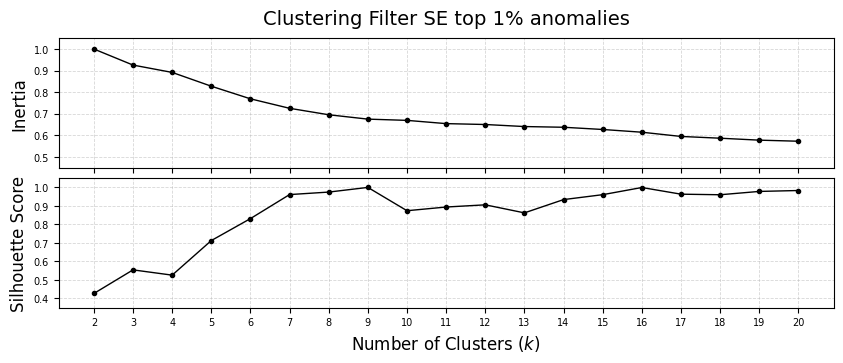

## Train data

In [12]:
X = weights_dict["norm_unique_norm_weights"]

## Train and save

In [13]:
# ```python
start_time = time.perf_counter()

kmeans_model = KMeans(n_clusters=n_clusters, random_state=0).fit(X)

end_time = time.perf_counter()
print(f"train time: {end_time - start_time:.2f} seconds")

# save model
joblib.dump(kmeans_model, f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
# ```

# ```python
# train time: 0.17 seconds
# [
# '/home/elom/phd/code/clustering/bin_03/mse_filter_250/
# kmeans_7_clusters_343_segments.joblib'
# ]
# ```

train time: 0.17 seconds


['/home/elom/phd/code/clustering/bin_03/mse_filter_250/kmeans_7_clusters_343_segments.joblib']

## Save metadata

In [14]:
# ```python
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
cluster_labels = kmeans_model.predict(X)

cluster_meta_df = meta_with_ratios_df.loc[specobjids_arr].copy()
cluster_meta_df["cluster"] = cluster_labels

# append score, specobjids_arr is already sorted by score
cluster_meta_df[score_name] = scores_df[score_name].loc[specobjids_arr].copy()
cluster_meta_df.to_csv(f"{kmeans_model_dir}/metadata.csv.gz", compression="gzip")

# Clusters metadata

In [15]:
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
cluster_labels = kmeans_model.predict(X)

# get spectra and weights per cluster
spectra_cluster_dict, weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=weights_dict["norm_weights"],
    print_n_clusters=True,
)

weights_dict["spectra_cluster_dict"] = spectra_cluster_dict
weights_dict["weights_cluster_dict"] = weights_cluster_dict


weights_dict["centroids"] = kmeans_model.cluster_centers_
# 0;71
# 1;258
# 2;142
# 3;427
# 4;246
# 5;461
# 6;214

0;71
1;258
2;142
3;427
4;246
5;461


6;214


In [16]:
cluster_meta_df = pd.read_csv(
    f"{kmeans_model_dir}/metadata.csv.gz", index_col="specobjid"
).loc[specobjids_arr]

# Line ratios

## Median line ratios

In [17]:
median_cluster_ratios_df = pd.DataFrame(
    index=range(0, n_clusters),
    columns=SDSS_NEBULAR_LINES_RATIOS_NAMES,
)
for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id

    median_cluster_ratios_df.loc[cluster_id, "balmer_decrement"] = np.nanmedian(
        cluster_meta_df.loc[mask, "balmer_decrement"]
    )
    median_cluster_ratios_df.loc[cluster_id, "nii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "nii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_hbeta"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_hbeta"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_oii"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_oii"]
    )
    median_cluster_ratios_df.loc[cluster_id, "o3n2_index"] = np.nanmedian(
        cluster_meta_df.loc[mask, "o3n2_index"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_density_ratio"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_density_ratio"]
    )
# map col name by replacing the '_' with ' ' for better readability
median_cluster_ratios_df.columns = [
    col.replace("_", " ") for col in median_cluster_ratios_df.columns
]

median_cluster_ratios_df.to_clipboard(excel=True, index=True)
median_cluster_ratios_df

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
0,3.828402,0.312105,0.920112,0.73536,0.29454,1.397221,0.50263
1,3.752899,0.353516,4.098946,4.129186,0.285638,1.299616,1.07137
2,3.270541,0.128233,1.834009,0.827347,0.267626,1.416227,1.173452
3,3.388395,0.148724,1.909393,1.403635,0.249791,1.384934,1.117759
4,3.948634,0.548389,0.973951,0.989999,0.331726,1.335699,0.184723
5,3.564689,0.335406,0.770767,0.766662,0.301533,1.398637,0.294997
6,4.001536,0.3561,1.509175,1.690023,0.261343,1.281114,0.681472


## Cluster 0 ratios percentiles

In [18]:
cluster_mask = cluster_meta_df["cluster"] == 0
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,50th,55th
balmer decrement,3.785097,3.828402,3.884732
nii to halpha,0.270846,0.312105,0.329574
oiii to hbeta,0.839400,0.920112,0.946184
oiii to oii,0.697140,0.735360,0.758714
sii to halpha,0.288110,0.294540,0.300566
sii density ratio,1.381167,1.397221,1.403827
o3n2 index,0.356454,0.502630,0.524429


## Cluster 1 ratios percentiles

In [19]:
cluster_mask = cluster_meta_df["cluster"] == 1
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,50th,55th
balmer decrement,3.688963,3.752899,3.868903
nii to halpha,0.300441,0.353516,0.478267
oiii to hbeta,3.879239,4.098946,4.260868
oiii to oii,3.712053,4.129186,4.861793
sii to halpha,0.271783,0.285638,0.304919
sii density ratio,1.273824,1.299616,1.316606
o3n2 index,1.024244,1.071370,1.171161


## Cluster 2 percentiles

In [20]:
cluster_mask = cluster_meta_df["cluster"] == 2
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,50th,55th
balmer decrement,3.210888,3.270541,3.350673
nii to halpha,0.113592,0.128233,0.147865
oiii to hbeta,1.662785,1.834009,1.988615
oiii to oii,0.823368,0.827347,0.831326
sii to halpha,0.257221,0.267626,0.279230
sii density ratio,1.410847,1.416227,1.419041
o3n2 index,1.099900,1.173452,1.238298


## Cluster 3 ratios percentiles

In [21]:
cluster_mask = cluster_meta_df["cluster"] == 3
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,50th,55th
balmer decrement,3.345005,3.388395,3.418453
nii to halpha,0.138901,0.148724,0.161700
oiii to hbeta,1.791396,1.909393,2.029378
oiii to oii,1.313593,1.403635,1.513329
sii to halpha,0.238767,0.249791,0.260782
sii density ratio,1.374351,1.384934,1.397037
o3n2 index,1.037758,1.117759,1.160694


## Cluster 4 ratios percentiles

In [22]:
cluster_mask = cluster_meta_df["cluster"] == 4
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,50th,55th
balmer decrement,3.854037,3.948634,4.036800
nii to halpha,0.506185,0.548389,0.628574
oiii to hbeta,0.899566,0.973951,1.151746
oiii to oii,0.883016,0.989999,1.095494
sii to halpha,0.314890,0.331726,0.381068
sii density ratio,1.308064,1.335699,1.351840
o3n2 index,0.131056,0.184723,0.259752


## Cluster 5 percentiles

In [23]:
cluster_mask = cluster_meta_df["cluster"] == 5
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,50th,55th
balmer decrement,3.398713,3.564689,3.669665
nii to halpha,0.314100,0.335406,0.353620
oiii to hbeta,0.685449,0.770767,0.893577
oiii to oii,0.677439,0.766662,0.862481
sii to halpha,0.292270,0.301533,0.311963
sii density ratio,1.380658,1.398637,1.415489
o3n2 index,0.197869,0.294997,0.379467


## Cluster 6 percentiles

In [24]:
cluster_mask = cluster_meta_df["cluster"] == 6
percentiles = np.arange(0.45, 0.60, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,50th,55th
balmer decrement,3.909074,4.001536,4.070598
nii to halpha,0.343637,0.356100,0.373401
oiii to hbeta,1.380014,1.509175,1.705328
oiii to oii,1.576809,1.690023,1.878595
sii to halpha,0.250743,0.261343,0.268435
sii density ratio,1.265156,1.281114,1.297700
o3n2 index,0.590298,0.681472,0.728561


# Redshift Analysis

In [25]:
z_dict = {"cluster": [], "z_min": [], "z_max": [], "z_mean": [], "z_median": []}

for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id
    z = cluster_meta_df["z"].loc[mask].values

    z_dict["cluster"].append(cluster_id)
    z_dict["z_min"].append(np.min(z))
    z_dict["z_max"].append(np.max(z))
    z_dict["z_mean"].append(np.mean(z))
    z_dict["z_median"].append(np.median(z))
z_df = pd.DataFrame(z_dict)
z_df

,cluster,z_min,z_max,z_mean,z_median
0,0,0.012621,0.135424,0.054481,0.058620
1,1,0.010132,0.243756,0.080490,0.085035
2,2,0.010093,0.151883,0.019629,0.013609
3,3,0.011578,0.251958,0.052581,0.033541
4,4,0.016985,0.229779,0.100418,0.090204
5,5,0.012135,0.294866,0.089070,0.073122
6,6,0.010354,0.282081,0.093910,0.107406


In [26]:
low_wave, upper_wave = 5_565, 5_590
z_df["lower_wave_min"] = low_wave / (1 + z_df["z_min"])
z_df["upper_wave_min"] = upper_wave / (1 + z_df["z_min"])
z_df["lower_wave_max"] = low_wave / (1 + z_df["z_max"])
z_df["upper_wave_max"] = upper_wave / (1 + z_df["z_max"])
z_df["lower_wave_mean"] = low_wave / (1 + z_df["z_mean"])
z_df["upper_wave_mean"] = upper_wave / (1 + z_df["z_mean"])
z_df["lower_wave_median"] = low_wave / (1 + z_df["z_median"])
z_df["upper_wave_median"] = upper_wave / (1 + z_df["z_median"])
z_df

,cluster,z_min,z_max,z_mean,z_median,lower_wave_min,upper_wave_min,lower_wave_max,upper_wave_max,lower_wave_mean,upper_wave_mean,lower_wave_median,upper_wave_median
0,0,0.012621,0.135424,0.054481,0.058620,5495.639045,5520.327450,4901.254906,4923.273122,5277.479619,5301.187973,5256.844610,5280.460264
1,1,0.010132,0.243756,0.080490,0.085035,5509.182778,5533.932027,4474.352073,4494.452487,5150.439118,5173.576760,5128.867023,5151.907756
2,2,0.010093,0.151883,0.019629,0.013609,5509.396417,5534.146625,4831.220676,4852.924273,5457.865272,5482.383984,5490.282498,5514.946840
3,3,0.011578,0.251958,0.052581,0.033541,5501.307240,5526.021109,4445.036228,4465.004945,5287.002295,5310.753428,5384.403864,5408.592560
4,4,0.016985,0.229779,0.100418,0.090204,5472.056949,5496.639415,4525.203309,4545.532165,5057.168413,5079.887049,5104.550926,5127.482422
5,5,0.012135,0.294866,0.089070,0.073122,5498.276871,5522.977126,4297.740346,4317.047356,5109.865739,5132.821111,5185.805356,5209.101876
6,6,0.010354,0.282081,0.093910,0.107406,5507.972000,5532.715810,4340.597692,4360.097233,5087.254292,5110.108084,5025.258811,5047.834098


# Clusters' XAI

## Centroid & Avg Spec

In [27]:
lw = 0.75
for label, centroid in enumerate(weights_dict["centroids"]):

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    centroid = clustering.expand_weights_per_segments(
        centroid.reshape(1, -1),
        wave_nm.size,
        n_segments,
    )
    centroid = clustering.normalize_weights_l2_abs(centroid).reshape(-1)
    avg_spectrum = weights_dict["spectra_cluster_dict"][label].mean(axis=0)

    axs[0].plot(
        wave_nm, avg_spectrum, color="black", label="Average spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, centroid, color="black", label="Centroid explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    # set limits
    axs[1].set_ylim(0, 0.31)
    y_ticks = np.arange(0, 0.31, 0.1)
    axs[1].set_yticks(y_ticks)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label}",
        fontsize=12,
    )

    plot_name = f"avg_spec_centroid_{label}"

    save_to = f"{kmeans_model_dir}/avg_spec_centroids"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Centroid & Median Spec

In [28]:
lw = 0.75
for label, centroid in enumerate(weights_dict["centroids"]):

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    centroid = clustering.expand_weights_per_segments(
        centroid.reshape(1, -1),
        wave_nm.size,
        n_segments,
    )
    centroid = clustering.normalize_weights_l2_abs(centroid).reshape(-1)
    _spec = weights_dict["spectra_cluster_dict"][label]
    med_spec = np.nanmedian(_spec, axis=0)

    axs[0].plot(
        wave_nm, med_spec, color="black", label="Median spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, centroid, color="black", label="Centroid explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    # set limits
    axs[1].set_ylim(0, 0.31)
    y_ticks = np.arange(0, 0.31, 0.1)
    axs[1].set_yticks(y_ticks)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label}",
        fontsize=12,
    )

    plot_name = f"median_spec_centroid_{label}"

    save_to = f"{kmeans_model_dir}/median_spec_centroids"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Avg Spec & XAI

In [29]:
lw = 0.75
for label_cluster, weights in weights_dict['weights_cluster_dict'].items():

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    spec = weights_dict["spectra_cluster_dict"][label_cluster]

    avg_spectrum = spec.mean(axis=0)
    avg_weights = weights.mean(axis=0)

    axs[0].plot(
        wave_nm, avg_spectrum, color="black", label="Average spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, avg_weights, color="black", label="Average explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 0.31)
    y_ticks = np.arange(0, 0.31, 0.1)
    axs[1].set_yticks(y_ticks)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label_cluster}",
        fontsize=12,
    )

    plot_name = f"avg_spec_xai_{label_cluster}"

    save_to = f"{kmeans_model_dir}/avg_spec_xai"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Median Spec & XAI

In [30]:
lw = 0.75
for label_cluster, weights in weights_dict['weights_cluster_dict'].items():

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    spec = weights_dict["spectra_cluster_dict"][label_cluster]

    median_spec = np.nanmedian(spec, axis=0)
    median_weights = np.nanmedian(weights, axis=0)

    axs[0].plot(
        wave_nm, median_spec, color="black", label="Median spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, median_weights, color="black", label="Median explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 0.31)
    y_ticks = np.arange(0, 0.31, 0.1)
    axs[1].set_yticks(y_ticks)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label_cluster}",
        fontsize=12,
    )

    plot_name = f"median_spec_xai_{label_cluster}"

    save_to = f"{kmeans_model_dir}/median_spec_xai"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

# Top ranked anomalies per cluster

In [55]:
cluster_id = 6

mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)

spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]

plot_top_ranked_explanations(
    cluster_id=cluster_id,
    metadata_df=metadata_df,
    spectra=spectra,
    norm_weights=norm_weights,
    wave=wave_nm,
    kmeans_model_dir=kmeans_model_dir,
    download_images=True,
    n_top_ranked=-1,
    max_norm_weights=False,
    # skip_ranks_list=[66]
)

Number of anomalies in cluster 6: 214


HTTPError: HTTP Error 500: Internal Server Error

## Check ranking

In [32]:
cluster_id = 0
mask = cluster_meta_df["cluster"] == cluster_id
metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)

spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]
metadata_df.loc[:, ["cluster", score_name]].head(10)
# scores_df.loc[mask].head(10)

,cluster,mse_filter_250
specobjid,,
2930814289679771648,0,15.932806
2723563214087415808,0,11.691047
3127826983174563840,0,9.596365
3323800087754205184,0,9.075703
1795914855333521408,0,7.976107
1194674128590759936,0,7.702778
1959146978059249664,0,7.381501
2908222068065593344,0,7.333923
1192355533059811328,0,6.723528


In [33]:
anomaly_rank = 0
cluster_id = 0

mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].sort_values(
    by=f"{score_name}", ascending=False
)

n_anomalies_in_cluster = metadata_df.shape[0]
print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

specobjid = metadata_df.index[anomaly_rank]
metadata_df.loc[specobjid, ["cluster", score_name]]

Number of anomalies in cluster 0: 71


cluster                   0
mse_filter_250    15.932806
Name: 2930814289679771648, dtype: object

# Cluster x

## Data prep

## Figure

# BPT

In [34]:
# from astroExplain.spectra.astronomy import BPT

# labels = [f"({i})" for i in range(1, 5)]
# log_n2_ha = np.array([-0.60, -0.32, -0.91, -0.82])
# log_o3_hb = np.array([0.14, 0.05, 0.57, 0.27])
# print(log_n2_ha)
# print(log_o3_hb)
# print(labels)

# fig, ax = plt.subplots(figsize=(10, 8))
# fig, ax = BPT.standar_bpt_plot(fig, ax, log_n2_ha, log_o3_hb, labels, xytext=(-5, 5))

# SDSS class

In [35]:
cluster_id = 0
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
STARBURST        52.112676
STARFORMING      28.169014
NaN              15.492958
AGN               2.816901
AGN BROADLINE     1.408451
Name: count, dtype: float64

In [36]:
cluster_id = 1
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
STARBURST                52.713178
AGN                      31.782946
AGN BROADLINE             9.689922
STARFORMING               3.488372
NaN                       1.550388
BROADLINE                 0.387597
STARFORMING BROADLINE     0.387597
Name: count, dtype: float64

In [37]:
cluster_id = 2
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
STARBURST      67.605634
STARFORMING    28.873239
NaN             3.521127
Name: count, dtype: float64

In [38]:
cluster_id = 3
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
STARBURST              85.948478
STARFORMING            11.241218
NaN                     1.873536
AGN                     0.468384
AGN BROADLINE           0.234192
STARBURST BROADLINE     0.234192
Name: count, dtype: float64

In [39]:
cluster_id = 4
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
NaN              49.593496
STARFORMING      20.731707
STARBURST        15.853659
AGN               8.536585
BROADLINE         3.658537
AGN BROADLINE     1.626016
Name: count, dtype: float64

In [40]:
cluster_id = 5
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
STARFORMING              39.045553
NaN                      29.501085
STARBURST                24.295011
AGN                       3.253796
BROADLINE                 2.603037
AGN BROADLINE             0.867679
STARFORMING BROADLINE     0.433839
Name: count, dtype: float64

In [41]:
cluster_id = 6
mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask]
# metadata_df.subClass.value_counts(dropna=False).to_clipboard()
metadata_df.subClass.value_counts(dropna=False)/mask.sum()*100

subClass
STARBURST                64.953271
AGN                      13.084112
STARFORMING              13.084112
AGN BROADLINE             4.205607
STARBURST BROADLINE       1.869159
NaN                       0.934579
BROADLINE                 0.934579
STARFORMING BROADLINE     0.934579
Name: count, dtype: float64